# 04 — Feature Engineering et Baseline naïve

## Projet : Smart City Energy Forecasting — Tetouan

Ce notebook correspond à la phase **Transformation / Feature Engineering** du pipeline KDD.

Objectifs :

- charger le dataset horaire propre issu du notebook `03_preprocessing.ipynb` ;
- créer les features temporelles, cycliques, calendaires, météo, lags et rolling ;
- vérifier la cohérence des features et l'absence de fuite de données ;
- sauvegarder `data/processed/tetouan_features.csv` ;
- calculer les baselines naïves : heure précédente, jour précédent, semaine précédente.

Cette phase prépare directement les notebooks de modélisation :

- `05_modeling_sarima_prophet.ipynb` ;
- `06_modeling_ml_xgboost.ipynb` ;
- `07_modeling_gru.ipynb`.

## 1. Imports et chemins du projet

Le notebook utilise les fonctions modulaires définies dans :

- `src/features.py` ;
- `src/models_baseline.py`.

Le code est conçu pour être exécuté depuis le dossier `notebooks/` ou depuis la racine du projet.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.features import (
    FeatureConfig,
    build_feature_dataset,
    check_rolling_no_leakage,
    get_model_feature_columns,
    load_holidays_from_csv,
    save_feature_dataset,
    validate_feature_dataset,
)

from src.models_baseline import (
    evaluate_naive_baselines,
    save_baseline_outputs,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "Tetuan City power consumption.csv"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"

RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"
FEATURE_COLUMNS_PATH = PROCESSED_DIR / "feature_columns.txt"

BASELINE_METRICS_PATH = RESULTS_METRICS_DIR / "baseline_naive_metrics.csv"
BASELINE_PRED_PATH = RESULTS_PRED_DIR / "baseline_naive_predictions.csv"
BASELINE_FIG_PATH = RESULTS_FIG_DIR / "baseline_naive_test_week.png"

for path in [
    PROCESSED_DIR,
    EXTERNAL_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_PRED_DIR,
    RESULTS_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan


## 2. Chargement du dataset horaire propre

La source recommandée est le fichier horaire propre produit par le prétraitement.

Le notebook cherche dans cet ordre :

1. `data/processed/tetouan_hourly_clean.csv`
2. `data/processed/tetouan_hourly.csv`

Si aucun de ces fichiers n'existe, le notebook reconstruit une version horaire depuis le CSV brut `data/raw/Tetuan City power consumption.csv`.

Cette reconstruction de secours permet d'exécuter le notebook même si le fichier horaire n'a pas encore été sauvegardé par le notebook 03.

In [2]:
COLUMN_MAPPING = {
    "DateTime": "datetime",
    "Temperature": "temperature",
    "Humidity": "humidity",
    "Wind Speed": "wind_speed",
    "general diffuse flows": "general_diffuse_flows",
    "diffuse flows": "diffuse_flows",
    "Zone 1 Power Consumption": "zone1_power",
    "Zone 2  Power Consumption": "zone2_power",
    "Zone 3  Power Consumption": "zone3_power",
}


def load_hourly_dataset(project_root: Path) -> pd.DataFrame:
    """
    Charge le dataset horaire propre si disponible.
    Sinon, reconstruit un dataset horaire à partir du CSV brut.
    """
    candidates = [
        project_root / "data" / "processed" / "tetouan_hourly_clean.csv",
        project_root / "data" / "processed" / "tetouan_hourly.csv",
    ]

    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)

            if "datetime" in df.columns:
                df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
                df = df.set_index("datetime")
            else:
                first_col = df.columns[0]
                df[first_col] = pd.to_datetime(df[first_col], errors="coerce")
                df = df.set_index(first_col)
                df.index.name = "datetime"

            df = df.sort_index()

            print(f"Dataset horaire chargé depuis : {path}")
            return df

    if not RAW_PATH.exists():
        raise FileNotFoundError(
            "Aucun fichier horaire trouvé et CSV brut introuvable. "
            "Vérifier data/processed/ ou data/raw/."
        )

    raw = pd.read_csv(RAW_PATH)
    raw = raw.rename(columns=COLUMN_MAPPING)

    raw["datetime"] = pd.to_datetime(raw["datetime"], errors="coerce")

    if raw["datetime"].isna().any():
        n_bad = int(raw["datetime"].isna().sum())
        raise ValueError(f"{n_bad} dates non convertibles détectées dans le CSV brut.")

    raw = raw.sort_values("datetime").set_index("datetime")

    for col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

    hourly = raw.resample("1h").mean()

    hourly["target"] = hourly["zone1_power"]
    hourly["total_load"] = (
        hourly["zone1_power"]
        + hourly["zone2_power"]
        + hourly["zone3_power"]
    )

    print("Aucun fichier horaire prétraité trouvé : dataset horaire reconstruit depuis le CSV brut.")

    return hourly


df_hourly = load_hourly_dataset(PROJECT_ROOT)

if "target" not in df_hourly.columns:
    df_hourly["target"] = df_hourly["zone1_power"]

if "total_load" not in df_hourly.columns:
    df_hourly["total_load"] = (
        df_hourly["zone1_power"]
        + df_hourly["zone2_power"]
        + df_hourly["zone3_power"]
    )

df_hourly = df_hourly.sort_index()

print("Dimensions du dataset horaire :", df_hourly.shape)
print("Période :", df_hourly.index.min(), "→", df_hourly.index.max())
print("Fréquence inférée :", pd.infer_freq(df_hourly.index))
print("Valeurs manquantes :", int(df_hourly.isna().sum().sum()))
print("Doublons temporels :", int(df_hourly.index.duplicated().sum()))

display(df_hourly.head())

Dataset horaire chargé depuis : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\data\processed\tetouan_hourly_clean.csv
Dimensions du dataset horaire : (8736, 15)
Période : 2017-01-01 00:00:00 → 2017-12-30 23:00:00
Fréquence inférée : h
Valeurs manquantes : 0
Doublons temporels : 0


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier
datetime,,,,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,29197.974683,66476.770597,0.0,0.0,0,0,0
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,24657.215190,57778.526210,0.0,0.0,0,0,0
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,22083.037973,52089.881640,0.0,0.0,0,0,0
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,20811.139240,48914.447548,0.0,0.0,0,0,0
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,20475.949367,47714.638347,0.0,0.0,0,0,0


## 3. Configuration du Feature Engineering

Les lags retenus suivent la logique temporelle du projet :

- `1h`, `2h`, `3h` : inertie immédiate ;
- `6h`, `12h` : dynamique intra-journalière ;
- `24h`, `48h`, `72h` : même heure les jours précédents ;
- `168h` : même heure la semaine précédente.

Les rolling features sont calculées à partir de la cible décalée avec `shift(1)`, donc elles n'utilisent jamais la valeur actuelle à prédire.

Le seuil de forte charge est calculé uniquement sur la partie train afin d'éviter toute fuite d'information depuis le futur.

In [3]:
config = FeatureConfig(
    target_col="target",
    temperature_col="temperature",
    humidity_col="humidity",
    general_diffuse_col="general_diffuse_flows",
    diffuse_col="diffuse_flows",
    temperature_base=18.0,
    lags=(1, 2, 3, 6, 12, 24, 48, 72, 168),
    rolling_windows=(3, 6, 12, 24, 48, 168),
    high_temperature_threshold=30.0,
    dropna_after_features=True,
)

train_end = int(len(df_hourly) * 0.70)

high_load_threshold_train = (
    df_hourly["target"]
    .iloc[:train_end]
    .quantile(config.high_load_quantile)
)

print(f"Seuil forte charge calculé sur train seulement : {high_load_threshold_train:.2f}")

Seuil forte charge calculé sur train seulement : 44816.11


## 4. Jours fériés marocains

Si `data/external/holidays_morocco.csv` existe, le notebook l'utilise.

Sinon, le module applique une liste indicative 2017 intégrée dans `src/features.py`.

Cette approximation doit être mentionnée dans le rapport final, surtout pour les jours religieux dont la date peut varier selon l'observation lunaire.

In [4]:
holidays_path = EXTERNAL_DIR / "holidays_morocco.csv"

if holidays_path.exists():
    holidays = load_holidays_from_csv(holidays_path)
    print(f"Jours fériés chargés depuis {holidays_path} : {len(holidays)} dates")
else:
    holidays = None
    print("Aucun fichier holidays_morocco.csv trouvé : utilisation de la liste indicative intégrée.")

Aucun fichier holidays_morocco.csv trouvé : utilisation de la liste indicative intégrée.


## 5. Création du dataset enrichi

Le dataset final conserve `target` pour l'entraînement supervisé.

Cependant, les colonnes de consommation directe :

- `zone1_power` ;
- `zone2_power` ;
- `zone3_power` ;
- `total_load`

seront exclues de la liste des variables explicatives pour éviter la fuite de cible.

Les lags et rolling features restent autorisés, car ils utilisent uniquement des valeurs passées.

In [5]:
df_features = build_feature_dataset(
    df_hourly,
    config=config,
    holidays=holidays,
    high_load_threshold=high_load_threshold_train,
)

feature_cols = get_model_feature_columns(
    df_features,
    target_col="target",
)

print("Dimensions avant feature engineering :", df_hourly.shape)
print("Dimensions après feature engineering :", df_features.shape)
print("Nombre de features utilisables par les modèles :", len(feature_cols))
print(
    "Lignes supprimées à cause des lags/rolling :",
    df_features.attrs.get("rows_dropped_after_features"),
)

display(df_features.head())

Dimensions avant feature engineering : (8736, 15)
Dimensions après feature engineering : (8568, 111)
Nombre de features utilisables par les modèles : 98
Lignes supprimées à cause des lags/rolling : 168


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,is_business_hour,is_morning_peak,is_evening_peak,is_peak_hour,is_off_peak,is_night,season,season_code,season_autumn,season_spring,season_summer,season_winter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_day_before_holiday,is_day_after_holiday,days_to_nearest_holiday,target_lag_1h,target_lag_2h,target_lag_3h,target_lag_6h,target_lag_12h,target_lag_24h,target_lag_48h,target_lag_72h,target_lag_168h,target_rolling_3h_mean,target_rolling_3h_std,target_rolling_3h_min,target_rolling_3h_max,target_rolling_6h_mean,target_rolling_6h_std,target_rolling_6h_min,target_rolling_6h_max,target_rolling_12h_mean,target_rolling_12h_std,target_rolling_12h_min,target_rolling_12h_max,target_rolling_24h_mean,target_rolling_24h_std,target_rolling_24h_min,target_rolling_24h_max,target_rolling_48h_mean,target_rolling_48h_std,target_rolling_48h_min,target_rolling_48h_max,target_rolling_168h_mean,target_rolling_168h_std,target_rolling_168h_min,target_rolling_168h_max,HDD,CDD,temperature_humidity_interaction,temperature_peak_interaction,CDD_peak_interaction,HDD_peak_interaction,general_diffuse_month_interaction,diffuse_month_interaction,temperature_lag_1h,humidity_lag_1h,HDD_lag_1h,CDD_lag_1h,temperature_lag_2h,humidity_lag_2h,HDD_lag_2h,CDD_lag_2h,temperature_lag_3h,humidity_lag_3h,HDD_lag_3h,CDD_lag_3h,temperature_lag_6h,humidity_lag_6h,HDD_lag_6h,CDD_lag_6h,temperature_lag_12h,humidity_lag_12h,HDD_lag_12h,CDD_lag_12h,is_high_temperature,is_heatwave_simulated,eval_is_high_load
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.273333,77.916667,0.0880,0.044667,0.123667,26633.924052,17421.276597,17871.807228,26633.924052,61927.007877,0.605689,0.402583,0,0,0,0,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,31526.075950,36025.316455,39227.341773,41583.797468,34033.417720,27193.924052,27172.658228,25979.746835,29197.974683,35592.911393,3158.861021,31526.075950,39227.341773,38309.704641,3528.606271,31526.075950,41583.797468,35676.624472,3851.666111,30612.658228,41583.797468,30612.700422,6430.701095,21502.784810,41583.797468,30662.468354,6600.138307,21453.164557,42924.556962,30102.121760,6962.283109,18540.759495,43572.658227,3.726667,0.0,1112.130556,0.0,0.0,0.0,0.044667,0.123667,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,13.070000,77.166667,4.930000,0.0,13.701667,72.591667,4.298333,0.0,14.575000,67.718333,3.425000,0.0,0,0,0
2017-01-08 01:00:00,14.441667,76.616667,0.0910,0.046500,0.137000,23640.506328,15492.401215,16057.831327,23640.506328,55190.738870,1.055631,0.858605,0,0,0,1,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,26633.924052,31526.075950,36025.316455,40846.582277,33486.582277,23961.518987,23968.607595,22892.151898,24657.215190,31395.105486,3835.138221,26633.924052,36025.316455,35818.059072,5213.136547,26633.924052,40846.582277,35060.000000,4587.406453,26633.924052,41583.797468,30589.367088,6444.065618,21502.784810,41583.797468,30651.244726,6606.518215,21453.164557,42924.556962,30086.859554,6967.057111,18540.759495,43572.658227,3.558333,0.0,1106.472361,0.0,0.0,0.0,0.046500,0.137000,14.273333,77.916667,3.726667,0.0,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,11.993333,79.133333,6.006667,0.0,14.928333,61.946667,3.071667,0.0,0,0,0
2017-01-08 02:00:00,14.216667,74.183333,0.0885,0.045833,0.123667,21817.721520,14072.340427,15021.686747,21817.721520,50911.748693,1.327609,1.149841,0,0,0,2,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.500000,0.866025,-0.781831,0.623

## 6. Contrôles de cohérence

Contrôles bloquants :

- index temporel trié ;
- absence de doublons ;
- absence de valeurs manquantes après suppression des premières lignes liées aux lags ;
- absence de valeurs infinies ;
- rolling means calculées uniquement sur le passé ;
- exclusion de `target`, `zone1_power` et `total_load` des features modèles.

In [6]:
validation_report = validate_feature_dataset(
    df_features,
    target_col="target",
    feature_cols=feature_cols + ["target"],
)

rolling_leakage_report = check_rolling_no_leakage(
    df_features,
    target_col="target",
    windows=(3, 6, 24, 168),
)

print("Rapport de validation :")
for key, value in validation_report.items():
    print(f"- {key}: {value}")

print("\nContrôle anti-leakage rolling :")
for col, ok in rolling_leakage_report.items():
    print(f"- {col}: {'OK' if ok else 'PROBLÈME'}")

assert all(rolling_leakage_report.values()), "Problème détecté dans les rolling features."

assert "target" not in feature_cols
assert "zone1_power" not in feature_cols
assert "total_load" not in feature_cols

print("\nValidation terminée : dataset features valide.")

Rapport de validation :
- n_rows: 8568
- n_columns: 111
- start: 2017-01-08 00:00:00
- end: 2017-12-30 23:00:00
- target_col: target
- n_model_features: 99
- n_missing: 0
- n_infinite: 0
- inferred_frequency: h

Contrôle anti-leakage rolling :
- target_rolling_3h_mean: OK
- target_rolling_6h_mean: OK
- target_rolling_24h_mean: OK
- target_rolling_168h_mean: OK

Validation terminée : dataset features valide.


## 7. Aperçu des features créées

Cette cellule permet de vérifier les familles de variables disponibles :

- variables temporelles ;
- encodage cyclique ;
- lags ;
- rolling features ;
- météo dérivée ;
- interactions ;
- variables de robustesse.

In [7]:
print("Nombre total de colonnes :", df_features.shape[1])
print("Nombre de features modèle :", len(feature_cols))

print("\nExemples de features modèle :")
display(pd.DataFrame({"feature": feature_cols}).head(40))

print("\nColonnes contenant 'lag' :")
display([col for col in df_features.columns if "lag" in col][:30])

print("\nColonnes contenant 'rolling' :")
display([col for col in df_features.columns if "rolling" in col][:30])

print("\nColonnes météo dérivées :")
weather_derived_cols = [
    col for col in df_features.columns
    if col in ["HDD", "CDD"]
    or "interaction" in col
    or col.startswith("HDD_lag")
    or col.startswith("CDD_lag")
]
display(weather_derived_cols)

Nombre total de colonnes : 111
Nombre de features modèle : 98

Exemples de features modèle :


,feature
0,temperature
1,humidity
2,wind_speed
3,general_diffuse_flows
4,diffuse_flows
5,hour
6,dayofweek
7,dayofmonth
8,dayofyear
9,weekofyear



Colonnes contenant 'lag' :


['target_lag_1h',
 'target_lag_2h',
 'target_lag_3h',
 'target_lag_6h',
 'target_lag_12h',
 'target_lag_24h',
 'target_lag_48h',
 'target_lag_72h',
 'target_lag_168h',
 'temperature_lag_1h',
 'humidity_lag_1h',
 'HDD_lag_1h',
 'CDD_lag_1h',
 'temperature_lag_2h',
 'humidity_lag_2h',
 'HDD_lag_2h',
 'CDD_lag_2h',
 'temperature_lag_3h',
 'humidity_lag_3h',
 'HDD_lag_3h',
 'CDD_lag_3h',
 'temperature_lag_6h',
 'humidity_lag_6h',
 'HDD_lag_6h',
 'CDD_lag_6h',
 'temperature_lag_12h',
 'humidity_lag_12h',
 'HDD_lag_12h',
 'CDD_lag_12h']


Colonnes contenant 'rolling' :


['target_rolling_zscore',
 'total_load_rolling_zscore',
 'target_rolling_3h_mean',
 'target_rolling_3h_std',
 'target_rolling_3h_min',
 'target_rolling_3h_max',
 'target_rolling_6h_mean',
 'target_rolling_6h_std',
 'target_rolling_6h_min',
 'target_rolling_6h_max',
 'target_rolling_12h_mean',
 'target_rolling_12h_std',
 'target_rolling_12h_min',
 'target_rolling_12h_max',
 'target_rolling_24h_mean',
 'target_rolling_24h_std',
 'target_rolling_24h_min',
 'target_rolling_24h_max',
 'target_rolling_48h_mean',
 'target_rolling_48h_std',
 'target_rolling_48h_min',
 'target_rolling_48h_max',
 'target_rolling_168h_mean',
 'target_rolling_168h_std',
 'target_rolling_168h_min',
 'target_rolling_168h_max']


Colonnes météo dérivées :


['HDD',
 'CDD',
 'temperature_humidity_interaction',
 'temperature_peak_interaction',
 'CDD_peak_interaction',
 'HDD_peak_interaction',
 'general_diffuse_month_interaction',
 'diffuse_month_interaction',
 'HDD_lag_1h',
 'CDD_lag_1h',
 'HDD_lag_2h',
 'CDD_lag_2h',
 'HDD_lag_3h',
 'CDD_lag_3h',
 'HDD_lag_6h',
 'CDD_lag_6h',
 'HDD_lag_12h',
 'CDD_lag_12h']

## 8. Sauvegarde du dataset features

Le fichier sauvegardé sera utilisé par les notebooks suivants :

- `05_modeling_sarima_prophet.ipynb` ;
- `06_modeling_ml_xgboost.ipynb` ;
- `07_modeling_gru.ipynb`.

La liste des features modèles est sauvegardée dans `data/processed/feature_columns.txt`.

In [8]:
features_path = save_feature_dataset(df_features, FEATURES_PATH)

FEATURE_COLUMNS_PATH.write_text(
    "\n".join(feature_cols),
    encoding="utf-8",
)

print(f"Dataset enrichi sauvegardé : {features_path}")
print(f"Liste des features modèle sauvegardée : {FEATURE_COLUMNS_PATH}")

Dataset enrichi sauvegardé : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv
Liste des features modèle sauvegardée : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\data\processed\feature_columns.txt


## 9. Baselines naïves

Les baselines naïves servent de minimum de performance.

Baselines utilisées :

- `naive_previous_hour` : prédit la valeur de l'heure précédente ;
- `naive_previous_day` : prédit la valeur de la même heure la veille ;
- `naive_previous_week` : prédit la valeur de la même heure la semaine précédente.

Un modèle avancé qui ne dépasse pas ces baselines n'apporte pas de valeur métier suffisante.

In [9]:
baseline_metrics, baseline_predictions = evaluate_naive_baselines(
    df_features,
    target_col="target",
    train_ratio=0.70,
    val_ratio=0.15,
)

save_baseline_outputs(
    baseline_metrics,
    baseline_predictions,
    BASELINE_METRICS_PATH,
    BASELINE_PRED_PATH,
)

print(f"Métriques baseline sauvegardées : {BASELINE_METRICS_PATH}")
print(f"Prédictions baseline sauvegardées : {BASELINE_PRED_PATH}")

display(baseline_metrics)

Métriques baseline sauvegardées : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\metrics\baseline_naive_metrics.csv
Prédictions baseline sauvegardées : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\predictions\baseline_naive_predictions.csv


,model,n_test_obs,MAE,RMSE,MAPE,R2
0,naive_previous_week,1286,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,1286,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1286,1745.006648,2300.125141,6.015784,0.853255


## 10. Visualisation rapide sur une semaine de test

Cette figure permet de vérifier visuellement si les baselines suivent correctement la saisonnalité de la cible.

On affiche la première semaine du test set.

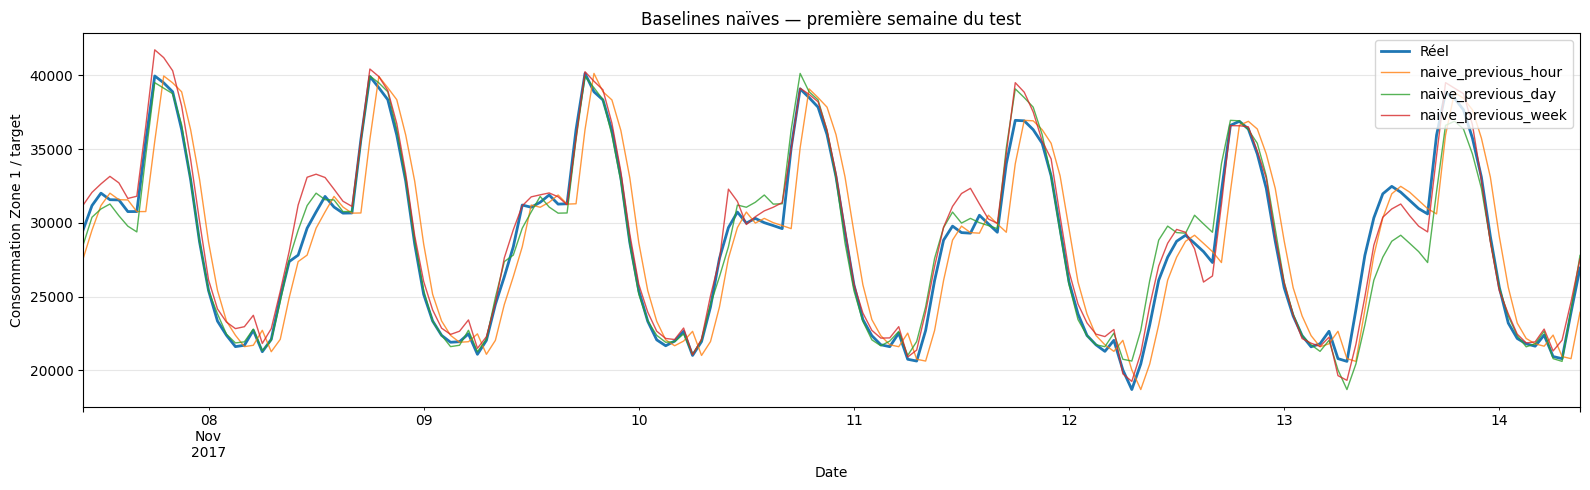

Figure sauvegardée : C:\Users\Badr\UB\0_Inbox\00-projects-code\dm-pfm-project\smart-city-energy-forecasting-tetouan\results\figures\baseline_naive_test_week.png


In [10]:
plot_df = baseline_predictions.dropna().copy().iloc[: 24 * 7]

fig, ax = plt.subplots(figsize=(16, 5))

plot_df["y_true"].plot(
    ax=ax,
    linewidth=2,
    label="Réel",
)

for col in ["naive_previous_hour", "naive_previous_day", "naive_previous_week"]:
    if col in plot_df.columns:
        plot_df[col].plot(
            ax=ax,
            linewidth=1,
            alpha=0.8,
            label=col,
        )

ax.set_title("Baselines naïves — première semaine du test")
ax.set_xlabel("Date")
ax.set_ylabel("Consommation Zone 1 / target")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASELINE_FIG_PATH, dpi=150)
plt.show()

print(f"Figure sauvegardée : {BASELINE_FIG_PATH}")

## 11. Analyse rapide des résultats baseline

Cette étape permet d'identifier quelle baseline naïve est la plus forte.

En général :

- si `naive_previous_hour` est très forte, cela indique une forte inertie immédiate ;
- si `naive_previous_day` est très forte, cela indique une forte saisonnalité journalière ;
- si `naive_previous_week` est très forte, cela indique une forte saisonnalité hebdomadaire.

Les modèles avancés devront dépasser la meilleure baseline.

In [11]:
best_baseline = baseline_metrics.iloc[0]

print("Meilleure baseline naïve :")
print(f"- Modèle : {best_baseline['model']}")
print(f"- MAE   : {best_baseline['MAE']:.2f}")
print(f"- RMSE  : {best_baseline['RMSE']:.2f}")
print(f"- MAPE  : {best_baseline['MAPE']:.2f}%")
print(f"- R2    : {best_baseline['R2']:.4f}")

print("\nInterprétation :")
print(
    "Cette baseline représente le seuil minimal à battre par les modèles avancés "
    "comme SARIMAX, Prophet, Random Forest, XGBoost et GRU."
)

Meilleure baseline naïve :
- Modèle : naive_previous_week
- MAE   : 792.88
- RMSE  : 1098.38
- MAPE  : 2.78%
- R2    : 0.9665

Interprétation :
Cette baseline représente le seuil minimal à battre par les modèles avancés comme SARIMAX, Prophet, Random Forest, XGBoost et GRU.


## 12. Synthèse pour le rapport final

Le feature engineering transforme la série horaire propre en dataset supervisé. Les variables calendaires et cycliques représentent les cycles d'activité humaine absents du dataset brut. Les lags et rolling features capturent la mémoire de la consommation, tandis que HDD/CDD modélisent la sensibilité thermique autour d'une température de confort de 18°C.

Les rolling statistics sont calculées avec `shift(1)`, ce qui empêche la valeur cible actuelle d'entrer dans ses propres variables explicatives. Les baselines naïves fournissent un seuil minimal de performance que les modèles SARIMAX, Prophet, Random Forest/XGBoost et GRU devront dépasser.

Point méthodologique important : les variables d'activité humaine ne sont pas directement observées dans le dataset Tetouan. Elles sont approximées par des proxys temporels et calendaires : heure, jour de semaine, week-end, saison, jours fériés, heures de pointe, heures creuses, lags journaliers et hebdomadaires.